In [1]:
import pandas as pd
import numpy as np
import sklearn


df = pd.read_csv("../data/data_transformed_main.csv").set_index(["ID на сайте", "Источник"])
df["Вид объекта"] = df["Вид объекта"].replace({
    'Офис/Здание': 'Офис / Здание',
    'Торговое / Свободное назначение': 'Торговое / Свободного назначения',
    'Торговое / свободного вида': 'Торговое / Свободного назначения',
    'Торговое/Свободного назначения': 'Торговое / Свободного назначения',
})
df["Москва?"] = df["Москва?"].replace({'False': 0, 'True': 1}).astype(float)
df.head()

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Цена / м2,Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офис / Здание,23.0,1500.0,0.0
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое / Свободного назначения,107.0,1500.0,0.0
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офис / Здание,830.0,1478.0,0.0
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офис / Здание,160.0,1478.0,0.0
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офис / Здание,1040.0,1478.0,0.0


In [2]:
df.dtypes

Цена                       float64
Дата                        object
Тип автора                  object
Город                       object
Метро/Район                 object
Адрес                       object
Описание                    object
lat                        float64
lng                        float64
URL                         object
Ссылки на картинки          object
Расстояние до метро, км    float64
Этаж                       float64
Этажность здания           float64
Вид объекта                 object
Общая площадь              float64
Цена / м2                  float64
Москва?                    float64
dtype: object

In [3]:
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, TargetEncoder,
    StandardScaler, MinMaxScaler, RobustScaler,
)

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

In [4]:
df.columns

Index(['Цена', 'Дата', 'Тип автора', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь', 'Цена / м2', 'Москва?'],
      dtype='object')

In [5]:
df.iloc[:2]["Тип автора"]

ID на сайте  Источник
321970859    cian.ru        Агентство
323570959    cian.ru     Частное лицо
Name: Тип автора, dtype: object

In [6]:
pd.get_dummies(df['Тип автора']).astype(int)

,,Агентство,Частное лицо
ID на сайте,Источник,,
321970859,cian.ru,1,0
323570959,cian.ru,0,1
319937619,cian.ru,1,0
319936797,cian.ru,1,0
319938233,cian.ru,1,0
...,...,...,...
4750280767,avito.ru,1,0
4750437026,avito.ru,1,0
4750004434,avito.ru,1,0


In [7]:
ohe = OneHotEncoder().fit(df[['Тип автора']])
ohe.transform(df[['Тип автора']]).toarray()

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(29559, 2))

In [8]:
ord_enc = OrdinalEncoder().fit(df[['Вид объекта']])
ord_enc.transform(df[['Вид объекта']])

array([[0.],
       [1.],
       [0.],
       ...,
       [0.],
       [0.],
       [1.]], shape=(29559, 1))

In [9]:
ord_enc.categories_

[array(['Офис / Здание', 'Торговое / Свободного назначения'], dtype=object)]

In [10]:
df.groupby("Вид объекта")["Цена"].mean()

Вид объекта
Офис / Здание                       496837.200929
Торговое / Свободного назначения    277255.474716
Name: Цена, dtype: float64

In [11]:
tar_enc = TargetEncoder(smooth=5).fit(df[['Вид объекта']], df["Цена"])
tar_enc.transform(df[['Вид объекта']])

array([[496754.84292232],
       [277272.21273862],
       [496754.84292232],
       ...,
       [496754.84292232],
       [496754.84292232],
       [277272.21273862]], shape=(29559, 1))

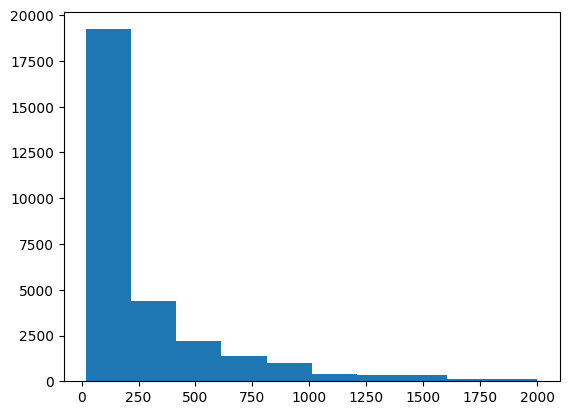

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["Общая площадь"])
plt.show()

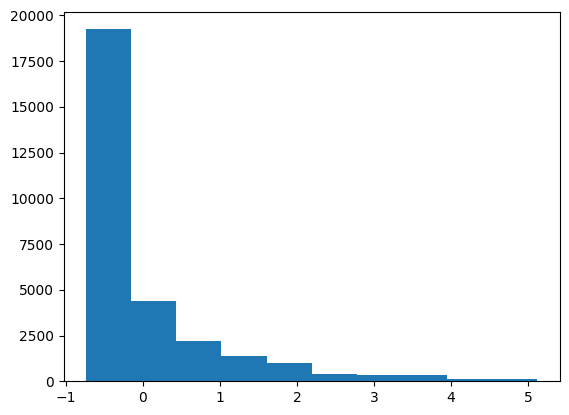

In [13]:
plt.hist(StandardScaler().fit_transform(df[["Общая площадь"]]))
plt.show()

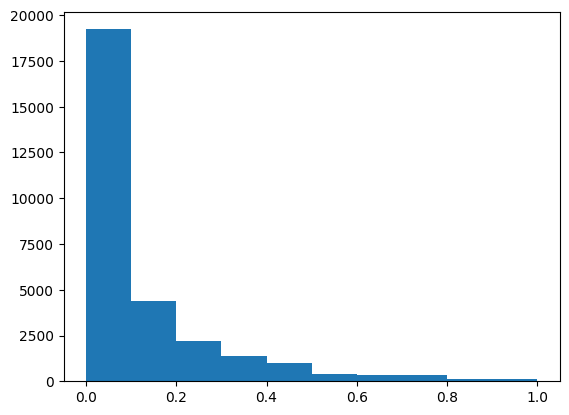

In [14]:
plt.hist(MinMaxScaler().fit_transform(df[["Общая площадь"]]))
plt.show()

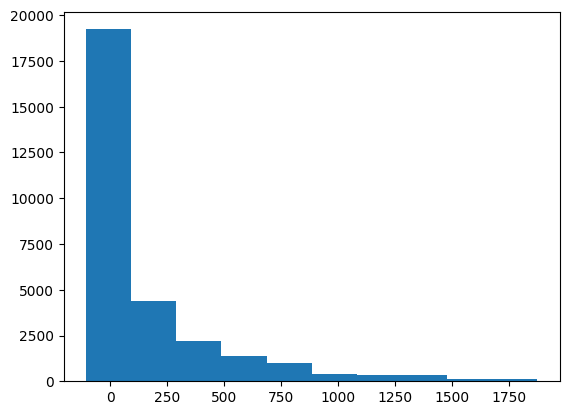

In [15]:
plt.hist(RobustScaler(quantile_range=(0.2, 0.8)).fit_transform(df[["Общая площадь"]]))
plt.show()

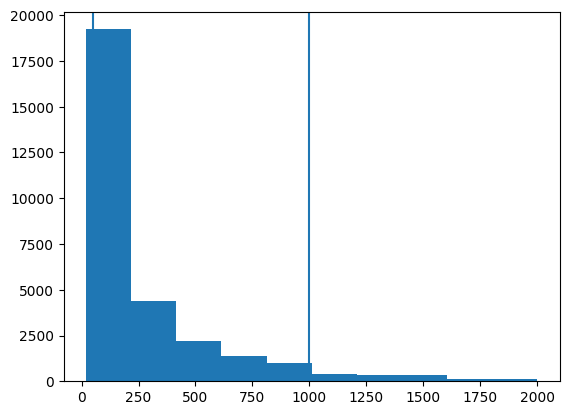

In [16]:
plt.hist(df["Общая площадь"])
plt.axvline(df["Общая площадь"].quantile(0.2))
plt.axvline(df["Общая площадь"].quantile(0.95))
plt.show()

In [17]:
df.columns

Index(['Цена', 'Дата', 'Тип автора', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь', 'Цена / м2', 'Москва?'],
      dtype='object')

In [18]:
from sklearn.compose import ColumnTransformer

from sklearn import set_config
set_config(transform_output="pandas")

ct = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км"]),
        ("onehot", OneHotEncoder(sparse_output=False), ["Вид объекта"]),
        ("ordinal", OrdinalEncoder(), ["Тип автора"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

ct.fit(df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [19]:
ct.transform(df)

,,scale__Общая площадь,"scale__Расстояние до метро, км",onehot__Вид объекта_Офис / Здание,onehot__Вид объекта_Торговое / Свободного назначения,ordinal__Тип автора,remainder__Цена,remainder__Дата,remainder__Город,remainder__Метро/Район,remainder__Адрес,remainder__Описание,remainder__lat,remainder__lng,remainder__URL,remainder__Ссылки на картинки,remainder__Этаж,remainder__Этажность здания,remainder__Цена / м2,remainder__Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,
321970859,cian.ru,-0.727409,-0.071871,1.0,0.0,0.0,34500.0,2025-12-17 08:36:40,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,4.0,4.0,1500.000000,0.0
323570959,cian.ru,-0.479083,-0.071871,0.0,1.0,1.0,160500.0,2025-12-17 08:36:40,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,1.0,1.0,1500.000000,0.0
319937619,cian.ru,1.658292,-0.071871,1.0,0.0,0.0,1226740.0,2025-12-17 08:36:40,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,2.0,6.0,1478.000000,0.0
319936797,cian.ru,-0.322401,-0.071871,1.0,0.0,0.0,236480.0,2025-12-17 08:36:39,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,2.0,6.0,1478.000000,0.0
319938233,cian.ru,2.279106,-0.071871,1.0,0.0,0.0,1537120.0,2025-12-17 08:36:38,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,2.0,6.0,1478.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4750280767,avito.ru,0.730322,-0.871338,1.0,0.0,0.0,736325.0,2025-02-28 14:19:30,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",НАЗВАНИЕ: Офисное помещение 516.12 кв.м от соб...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,https://30.img.avito.st/image/1/1.AlU-sba5rrwI...,1.0,NaN,1426.709940,0.0
4750437026,avito.ru,-0.256772,-0.838334,1.0,0.0,0.0,270000.0,2025-02-28 14:19:23,Котельники,Котельники,"Московская обл., Котельники, Дзержинское ш., 2",НАЗВАНИЕ: Офисное помещение 182.24 кв.м от соб...,55.654477,37.856443,https://www.avito.ru/kotelniki/kommercheskaya_...,https://10.img.avito.st/image/1/1.xz3K9La5a9T8...,5.0,NaN,1481.888035,0.0
4750004434,avito.ru,0.744808,-0.871338,1.0,0.0,0.0,743442.0,2025-02-28 14:19:06,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",НАЗВАНИЕ: Офисное помещение 521 кв.м от собств...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,https://70.img.avito.st/image/1/1.y5athra5Z3-b...,1.0,NaN,1426.952015,0.0


In [20]:
df.shape

(29559, 18)

In [26]:
from sklearn.model_selection import train_test_split

y = df["Цена"].copy()
X = df[["Общая площадь", "Расстояние до метро, км", "Вид объекта", "Тип автора", "Москва?", "Метро/Район"]].copy()
X['Метро/Район'] = X['Метро/Район'].fillna('')
#print(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=X["Вид объекта"])

In [27]:
X_train["Вид объекта"].value_counts() / X_train.shape[0] * 100

Вид объекта
Торговое / Свободного назначения    68.929586
Офис / Здание                       31.070414
Name: count, dtype: float64

In [28]:
X_test["Вид объекта"].value_counts() / X_test.shape[0] * 100

Вид объекта
Торговое / Свободного назначения    68.930988
Офис / Здание                       31.069012
Name: count, dtype: float64

In [29]:
X_test.isna().sum()

Общая площадь                 0
Расстояние до метро, км    2210
Вид объекта                   0
Тип автора                    0
Москва?                       0
Метро/Район                   0
dtype: int64

In [30]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy="constant", fill_value=100, add_indicator=True).fit(X_train[["Расстояние до метро, км"]])
X_train_fillna = si.transform(X_train[["Расстояние до метро, км"]])
X_test_fillna = si.transform(X_test[["Расстояние до метро, км"]])

In [31]:
X_train = pd.concat([X_train.drop("Расстояние до метро, км", axis=1), X_train_fillna], axis=1)
X_test = pd.concat([X_test.drop("Расстояние до метро, км", axis=1), X_test_fillna], axis=1)

X_train.head()

,,Общая площадь,Вид объекта,Тип автора,Москва?,Метро/Район,"Расстояние до метро, км","missingindicator_Расстояние до метро, км"
ID на сайте,Источник,,,,,,,
316126777,cian.ru,90.0,Торговое / Свободного назначения,Частное лицо,0.0,,100.000,1.0
319910998,cian.ru,102.0,Торговое / Свободного назначения,Агентство,0.0,Котельники,17.417,0.0
317566732,cian.ru,2000.0,Торговое / Свободного назначения,Агентство,0.0,Удельная,20.167,0.0
322240461,cian.ru,32.0,Торговое / Свободного назначения,Агентство,0.0,Красногорская,6.417,0.0
7537948086,avito.ru,1567.0,Офис / Здание,Агентство,0.0,Остафьево,1.000,0.0


In [38]:
ct = ColumnTransformer(
    transformers=[
        
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км"]),
        ("onehot", OneHotEncoder(sparse_output=False), ["Вид объекта"]),
        ("ordinal", OrdinalEncoder(), ["Тип автора", "Метро/Район"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

ct.fit(X)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [39]:
ct.transform(X_test)["ordinal__Метро/Район"].unique()

array([184.,   0., 261., 143., 205., 255., 109., 182., 268.,  93.,  35.,
       195., 201., 196., 162.,  70., 132., 289., 192., 254.,  45., 210.,
       179., 148.,  39., 172., 163.,  91., 129.,  97., 216., 153., 165.,
       242., 146.,  69., 281.,  36., 208., 199., 204., 180., 247.,  47.,
        88., 110., 283.,  25., 258., 235., 203.,  48., 152., 177.,  64.,
       243., 227., 170., 102., 127., 194.,  96.,  74., 131., 161., 160.,
        52.,  84., 136., 116., 187.,  51., 175., 214., 124., 197.,  55.,
       155., 113., 157., 257., 128.,  49., 299., 237.,  28., 238., 150.,
       168.,  30.,  79.,  16., 263., 139., 272., 259.,  53.,  73., 280.,
       154.,  26., 221., 159., 134., 122., 202.,  90., 284., 225., 209.,
        23., 188.,  89., 265.,  27.,  29., 215., 226., 206., 300., 120.,
       213., 278., 285., 125., 233., 295., 262., 198., 274., 228., 100.,
        58., 112., 248., 244., 145.,  31., 298., 121., 234., 207., 288.,
        87., 241.,  92., 178., 291., 218., 267., 22

In [40]:
X_train_pre = ct.transform(X_train)
X_test_pre = ct.transform(X_test)

In [41]:
model = LinearRegression().fit(X_train_pre, y_train)
y_pred = model.predict(X_train_pre)
y_test_pred = model.predict(X_test_pre)

r2_score(y_train, y_pred), rmse(y_train, y_pred), mape(y_train, y_pred)

(0.7285605367270644, 220705.0083109225, 0.6997048501041426)

In [42]:
r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

(0.7203168124937396, 221574.1832794684, 0.6970708990218719)

In [43]:
import seaborn as sns
def draw_test(y_test, y_test_pred, y_train, y_pred):
    fig, axis = plt.subplots(ncols=2)
    sns.regplot(x=y_test, y=y_test_pred, ax=axis[0])
    sns.regplot(x=y_train, y=y_pred, ax=axis[1])
    
    for i, y_true in enumerate([y_test, y_train]):
        lims = [np.min(y_true), np.max(y_true)]
        axis[i].plot(lims, lims, linestyle="--", color="black", label="Идеальная модель")
    
    axis[0].set_title("Тест")
    axis[1].set_title("Обучение")
    for i in [0, 1]:
        axis[i].set_xlabel("Таргет")
        axis[i].set_ylabel("Прогноз")
        axis[i].legend()
    plt.show()

In [44]:
import sys

sys.path.append("..")

import viz

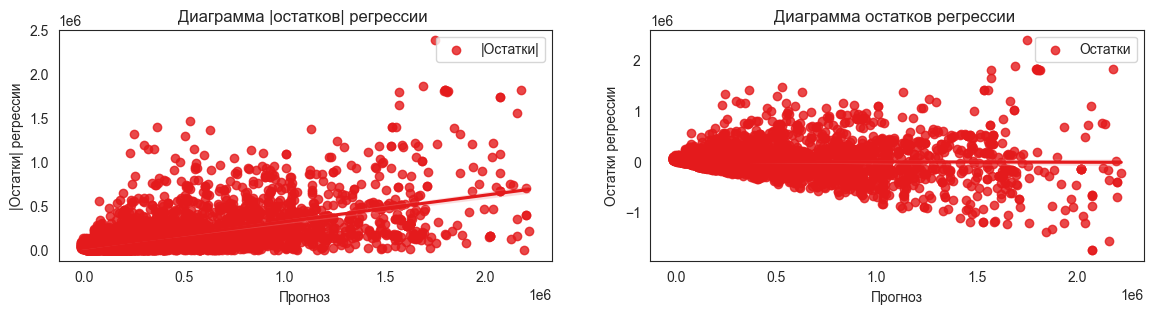

In [45]:
viz.plot_regression_residuals(y_test, y_test_pred)

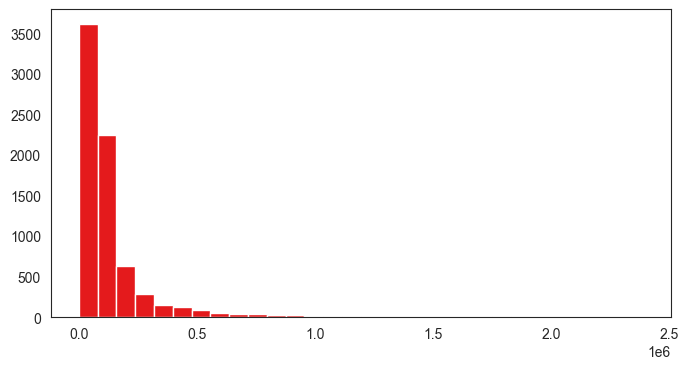

In [46]:
plt.hist(np.abs(y_test - y_test_pred), bins=30)
plt.show()

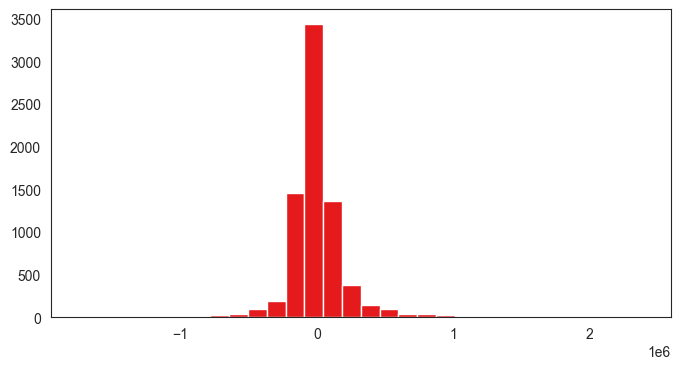

In [47]:
plt.hist(y_test - y_test_pred, bins=30)
plt.show()

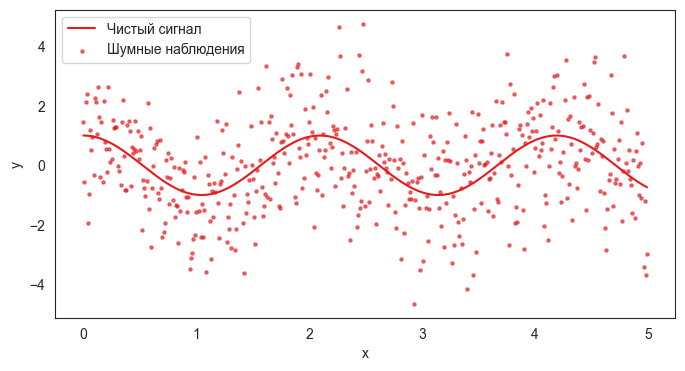

In [48]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # фиксируем сид для воспроизводимости

Xs = np.arange(0, 500) / 100
signal = np.cos(3 * Xs)

noise = rng.normal(loc=0.0, scale=1.5, size=len(Xs))  # N(0, 2^2)
ys = signal + noise

plt.figure(figsize=(8, 4))
plt.plot(Xs, signal, label="Чистый сигнал")
plt.scatter(Xs, ys, s=5, alpha=0.6, label="Шумные наблюдения")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

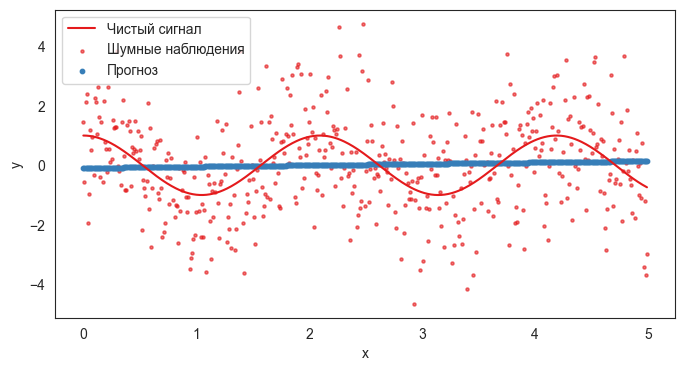

In [49]:
lrs = LinearRegression().fit(Xs.reshape(-1, 1), ys)
ys_pred = lrs.predict(Xs.reshape(-1, 1))

plt.figure(figsize=(8, 4))
plt.plot(Xs, signal, label="Чистый сигнал")
plt.scatter(Xs, ys, s=5, alpha=0.6, label="Шумные наблюдения")
plt.scatter(Xs, ys_pred, s=10, label="Прогноз")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

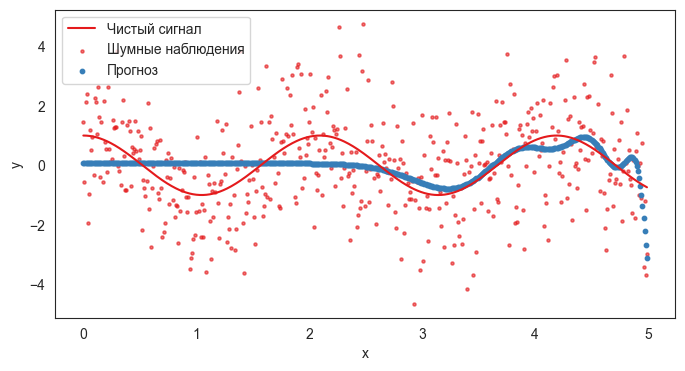

In [50]:
from sklearn.preprocessing import PolynomialFeatures

Xsp = PolynomialFeatures(degree=30).fit_transform(Xs.reshape(-1, 1)).drop("1", axis=1)

lrs = LinearRegression().fit(Xsp, ys)
ys_pred = lrs.predict(Xsp)

plt.figure(figsize=(8, 4))
plt.plot(Xs, signal, label="Чистый сигнал")
plt.scatter(Xs, ys, s=5, alpha=0.6, label="Шумные наблюдения")
plt.scatter(Xs, ys_pred, s=10, label="Прогноз")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [51]:
import optuna
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
optuna.logging.set_verbosity(optuna.logging.WARNING)


FIXED_KWARGS = {
    'tol': 1e-5,
    'random_state': 42,
}

CV = KFold(n_splits=5, random_state=10, shuffle=True)

def objective(trial, X, y):
    params = {
        'alpha': trial.suggest_float('alpha', low=0.0001, high=50),
        'max_iter': trial.suggest_int('max_iter', low=300, high=3000),
        'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
    }
    
    params.update(FIXED_KWARGS)
    model = Ridge(**params).fit(X, y)
    scores = cross_validate(
        model,
        X, y,
        scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
        cv=CV,
        n_jobs=-1,
    )
    return scores['test_score'].mean()


def study_results(study):
    trial = study.best_trial
    print('Best CV={} score: {:.6}'.format(CV, trial.value))
    print('Best params:')
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))


def plot_study(study):
    fig_list = [
        optuna.visualization.plot_optimization_history(study),
        optuna.visualization.plot_param_importances(study),
    ]
    for fig in fig_list:
        fig.update_layout(width=900)
        fig.show()

In [52]:
# study = optuna.create_study(
#         sampler=optuna.samplers.TPESampler(),
#         pruner=optuna.pruners.HyperbandPruner(),
#         direction="maximize",
# )

# study.optimize(lambda trial: objective(trial, X_train_pre, y_train),
#                   n_trials=1000, timeout=300, gc_after_trial=True, show_progress_bar=True)

# study_results(study)
# plot_study(study)

In [53]:
# params = study.best_trial.params
# params.update(FIXED_KWARGS)

# model = Ridge(**params).fit(X_train_pre, y_train)
# y_test_pred = model.predict(X_test_pre)
# r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

## CatBoost

In [56]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(verbose=False).fit(X_train_pre, y_train)
y_test_pred = model.predict(X_test_pre)
r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

(0.831360163543439, 172054.51077902055, 0.4555069761157185)

In [58]:
r2_score(y_train, y_pred), rmse(y_train, y_pred), mape(y_train, y_pred)

(0.7285605367270644, 220705.0083109225, 0.6997048501041426)

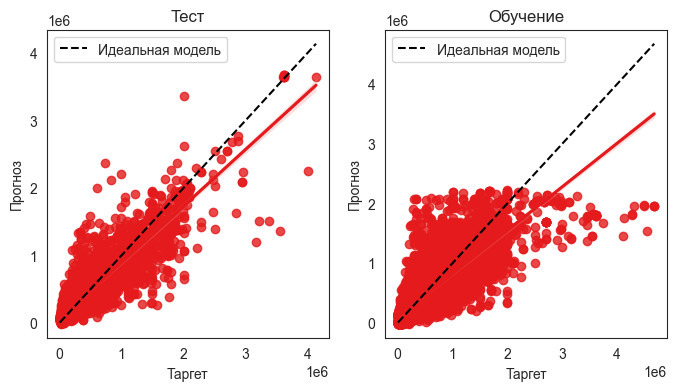

In [57]:
draw_test(y_test, y_test_pred, y_train, y_pred)

In [ ]:
# FIXED_KWARGS = {
#     'logging_level': 'Silent',
#     'loss_function': 'RMSE',
#     'random_state': 10,
# }

# def objective(trial, X, y):
#     params = {
#         'iterations': trial.suggest_categorical('iterations', [50, 100, 200, 300, 500, 750, 1000]),
#         'depth': trial.suggest_int('depth', low=3, high=6),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', low=1e-6, high=100.0, log=True),
#         'learning_rate': trial.suggest_float('learning_rate', low=1e-4, high=5e-1), # log=True
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', low=5, high=25),
#         'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.3, 1.0),
#         'subsample': trial.suggest_float('subsample', low=0.3, high=1.0),
#         'early_stopping_rounds': 200,
#     }
    
#     params.update(FIXED_KWARGS)
#     model = CatBoostRegressor(**params).fit(X, y)
#     scores = cross_validate(
#         model,
#         X, y,
#         scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
#         cv=CV,
#         n_jobs=-1,
#     )
#     return scores['test_score'].mean()

In [ ]:
# study = optuna.create_study(
#         sampler=optuna.samplers.TPESampler(),
#         pruner=optuna.pruners.HyperbandPruner(),
#         direction="maximize",
# )

# study.optimize(lambda trial: objective(trial, X_train_pre, y_train),
#                   n_trials=1000, timeout=180, gc_after_trial=True, show_progress_bar=True)

# study_results(study)
# plot_study(study)

In [ ]:
# params = study.best_trial.params
# params.update(FIXED_KWARGS)

# model = CatBoostRegressor(**params).fit(X_train_pre, y_train)
# y_test_pred = model.predict(X_test_pre)
# r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

# Обработка текстов

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stops = set(stopwords.words('russian'))

**Обработка регулярками**

In [ ]:
df["Описание2"] = df["Описание"].str.replace("НАЗВАНИЕ: ", "").str.replace("ОПИСАНИЕ: ", "").str.lower()
df["Описание2"] = df["Описание2"].str.replace(r"[^a-zа-яё\d]", " ", regex=True).str.replace(r"\d+", "", regex=True)
df["Описание2"] = df["Описание2"].str.replace(r"\s+", " ", regex=True)
df["Описание2"] = df["Описание2"].str.lower().str.strip()
df["Описание2"] = df["Описание2"].fillna("")

def replace_letter(text):
    for eng, ru in {
                    "a": "а",
                    "b": "в",
                    "c": "с",
                    "o": "о",
                    "y": "у",
                    "m": "м",
                    "e": "е",
                    "p": "р",
                    "h": "н",
                    "t": "т",
                    "x": "х",
                    "k": "к",
                }.items():
        text = text.replace(eng, ru)
    return text

df["Описание2"] = df["Описание2"].apply(replace_letter)

In [ ]:
s = df.sample()
s["Описание2"].values[0]

In [ ]:
s["Описание"].values[0]

In [ ]:
import pymorphy2

morph = pymorphy2.MorphAnalyzer(lang='ru')

def get_norm_form(word):
    return morph.parse(word)[0].normal_form

def normalize_text(text):
    splitted = [get_norm_form(w) for w in text.split()]
    splitted = [w for w in splitted if w not in stops]
    return " ".join(splitted)

In [ ]:
%%time
df["Описание2"] = df["Описание2"].apply(normalize_text)
df[["Описание", "Описание2"]].to_excel("../data/Описания.xlsx")

**Разделение выборок**

In [ ]:
X_train_pre.loc[:, "Описание2"] = df.loc[X_train_pre.index, "Описание2"]
X_test_pre.loc[:, "Описание2"] = df.loc[X_test_pre.index, "Описание2"]

**Удаление квантилей слов**

In [ ]:
from nltk.probability import FreqDist

fd_counter = FreqDist()
_ = X_train_pre["Описание2"].apply(lambda text: fd_counter.update(text.split()))
len(fd_counter), fd_counter

In [ ]:
wc = pd.DataFrame(fd_counter.most_common(), columns=["word", "count"]).set_index("word")["count"]
wc.head(20)

In [ ]:
wc.sort_index()

In [ ]:
wc.tail(20)

In [ ]:
sns.histplot(wc.values, bins=50)
plt.show()

In [ ]:
wc.describe(percentiles=(0.25, 0.5, 0.75, 0.8, 0.9))

**Фильтрация по числу вхождений**

In [ ]:
LOW, HIGH = 5, 15000
vocab = {k: v for k, v in dict(fd_counter).items() if v <= HIGH and v >= LOW}
len(vocab)

**Кластеризация + отрисовка**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(vocabulary=list(vocab)).fit(X_train_pre["Описание2"].values)
train_bow = vectorizer.transform(X_train_pre["Описание2"].values)
test_bow = vectorizer.transform(X_test_pre["Описание2"].values)

train_bow

In [ ]:
dict(sorted(vectorizer.vocabulary_.items(), key=lambda x: x[1])[::-1])

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation as LDA

lda_kwargs = {
    'learning_method': 'online',
    'batch_size': 256,
    'learning_decay': 0.95,
    'n_components': 5,
    'random_state': 10,
    'max_iter': 20,
    'n_jobs': -1,
}

lda = LDA(**lda_kwargs).fit(train_bow)
labels_train_lda = np.argmax(lda.transform(train_bow), axis=1)
labels_test_lda = np.argmax(lda.transform(test_bow), axis=1)

In [ ]:
!pip install -q wordcloud

In [ ]:
from wordcloud import WordCloud

def draw_wordcloud(texts, max_words=1000, width=900, height=400, random_state=10):
    wordcloud = WordCloud(background_color='white', max_words=max_words,
                          width=width, height=height, random_state=random_state)

    joint_texts = ' '.join(list(texts))
    wordcloud.generate(joint_texts)
    return wordcloud.to_image()

def draw_cluster_clouds(texts_words, clusters, n_clusters, **cloud_kwargs):
    for k in range(n_clusters):
        inds = np.argwhere(clusters == k).reshape((-1,))
        print('cluster: {}; samples: {}'.format(k + 1, len(inds)))
        if len(inds) == 0:
            print('empty')
            continue
        display(draw_wordcloud(texts_words[inds], **cloud_kwargs))

In [ ]:
words = vectorizer.get_feature_names_out()
text_words_count = train_bow.toarray()
text_words_mask = (text_words_count > 0)

reconstructed_texts = []
for mask in text_words_mask:
    reconstructed_texts.append(' '.join(words[mask]))
reconstructed_texts = np.asarray(reconstructed_texts)

In [ ]:
cloud_kwargs = { 'max_words': 300, 'width': 900, 'height': 250 }
draw_cluster_clouds(reconstructed_texts, labels_train_lda, lda_kwargs['n_components'], **cloud_kwargs)

In [ ]:
X_train_lda = X_train_pre.drop("Описание2", axis=1)
X_test_lda = X_test_pre.drop("Описание2", axis=1)

model = LinearRegression().fit(X_train_lda, y_train)
y_pred = model.predict(X_train_lda)
y_test_pred = model.predict(X_test_lda)

print("train:")
print(r2_score(y_train, y_pred), rmse(y_train, y_pred), mape(y_train, y_pred))
print("test:")
print(r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred))

In [ ]:
X_train_lda["desc_cluster"] = labels_train_lda
X_test_lda["desc_cluster"] = labels_test_lda

model = LinearRegression().fit(X_train_lda, y_train)
y_pred = model.predict(X_train_lda)
y_test_pred = model.predict(X_test_lda)

print("train:")
print(r2_score(y_train, y_pred), rmse(y_train, y_pred), mape(y_train, y_pred))
print("test:")
print(r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred))

In [ ]:
_ = sns.boxplot(x=y_train, hue=X_train_lda["desc_cluster"])